In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

start = '2012-01-01'
end = '2022-12-31'

stock = 'GOOG'

data = yf.download(stock, start, end)
data.reset_index(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [2]:
print(data)

Price        Date      Close       High        Low       Open     Volume
Ticker                  GOOG       GOOG       GOOG       GOOG       GOOG
0      2012-01-03  16.417624  16.485228  16.095888  16.109953  147611217
1      2012-01-04  16.488438  16.537044  16.299443  16.408251  114989399
2      2012-01-05  16.259720  16.382098  16.191129  16.336700  131808205
3      2012-01-06  16.037910  16.284146  16.032235  16.263173  108119746
4      2012-01-09  15.357923  15.963398  15.327574  15.951059  233776981
...           ...        ...        ...        ...        ...        ...
2763   2022-12-23  88.967323  89.254603  86.797877  86.797877   17815000
2764   2022-12-27  87.104973  88.660242  86.713682  88.472022   15470900
2765   2022-12-28  85.648766  87.689435  85.559614  86.679008   17879600
2766   2022-12-29  88.115402  88.526509  86.173793  86.213419   18280700
2767   2022-12-30  87.897476  87.996536  86.213422  86.545278   19190300

[2768 rows x 6 columns]


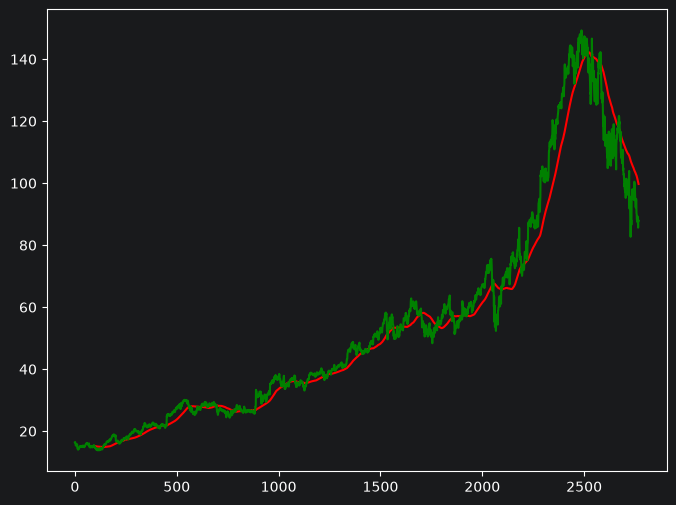

In [3]:
ma_100_days = data.Close.rolling(100).mean()
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

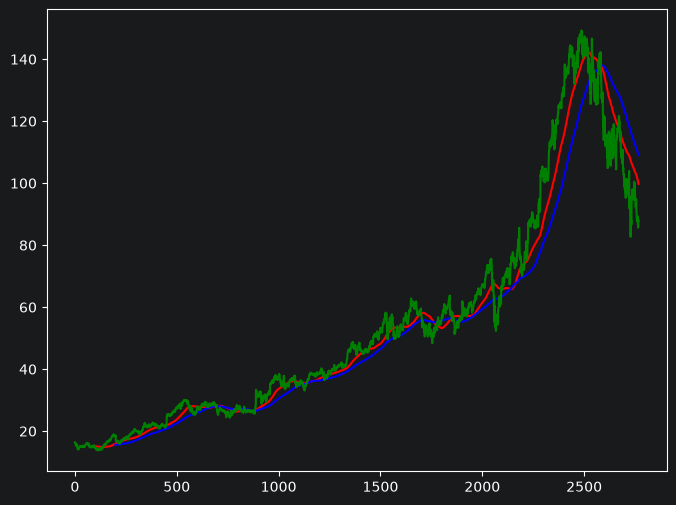

In [4]:
ma_200_days = data.Close.rolling(200).mean()
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days, 'b')
plt.plot(data.Close, 'g')
plt.show()

In [5]:
data.dropna(inplace=True)
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [6]:
data_train.shape[0]

2214

In [7]:
data_test.shape[0]

554

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [9]:
data_train_scale = scaler.fit_transform(data_train)

In [10]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [11]:
x,y = np.array(x), np.array(y)

In [12]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [13]:
model = Sequential()

model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/Users/mlyl/PycharmProjects/WelcomeScreen/.venv/lib/python3.14/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x,y, epochs = 50, batch_size = 32, verbose = 1)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0307
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0066
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0055
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0058
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0050
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0052
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0055
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0041
Epoch 9/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0038
Epoch 10/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0046
Epoch 11/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0038
Epoch 12/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0045
Epoch 13/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0038
Epoch 14/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0048
Epoch 15/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0032
Epoc

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [16]:
pas_100_days = data_train.tail(100)
data_test = pd.concat([pas_100_days, data_test], ignore_index = True)


In [17]:
data_test_scale = scaler.fit_transform(data_test)

In [18]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])

x,y = np.array(x), np.array(y)

In [19]:
y_predict = model.predict(x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step 


In [20]:
y_predict

array([[0.11816424],
       [0.12226659],
       [0.12658095],
       [0.13111387],
       [0.13593647],
       [0.14094327],
       [0.14604262],
       [0.15091829],
       [0.15535785],
       [0.15934539],
       [0.1629542 ],
       [0.16634163],
       [0.16989908],
       [0.17393805],
       [0.17867412],
       [0.1841954 ],
       [0.19036198],
       [0.19696516],
       [0.20380202],
       [0.21070978],
       [0.21753362],
       [0.22406287],
       [0.2301252 ],
       [0.23559187],
       [0.2403037 ],
       [0.24410808],
       [0.24701053],
       [0.2491073 ],
       [0.2505836 ],
       [0.25158778],
       [0.25234982],
       [0.25316346],
       [0.2542677 ],
       [0.25582987],
       [0.25789624],
       [0.2604708 ],
       [0.263385  ],
       [0.26642433],
       [0.2693674 ],
       [0.2720071 ],
       [0.27414846],
       [0.27562052],
       [0.27629763],
       [0.27608138],
       [0.2749312 ],
       [0.27287674],
       [0.27003407],
       [0.266

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
y_predict_rescaled = scaler.inverse_transform(y_predict.reshape(-1, 1))
y_rescaled = scaler.inverse_transform(y.reshape(-1, 1))

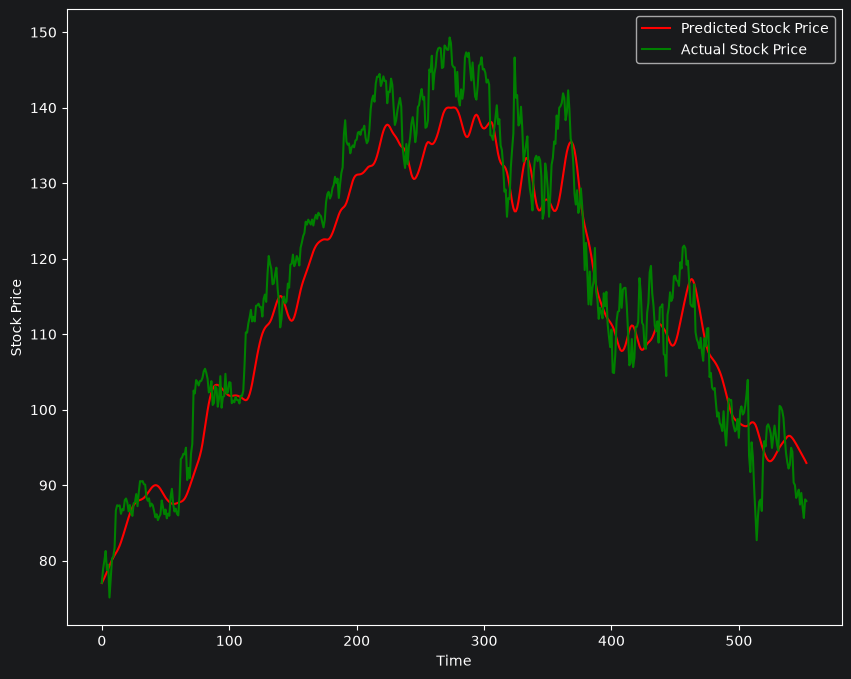

In [23]:
plt.figure(figsize=(10,8))
plt.plot(y_predict_rescaled, 'r', label='Predicted Stock Price')
plt.plot(y_rescaled, 'g', label='Actual Stock Price')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [24]:
model.save('Stock Prediction Model.keras')